# Experiment No. 1

## Title
**To implement the Digital Differential Analyzer (DDA) algorithm for drawing a straight line between two points**

## Objective
To generate a straight line between two given points using the DDA line drawing algorithm and observe pixel plotting behavior.

## Theory
The Digital Differential Analyzer (DDA) is a line drawing algorithm used in computer graphics to interpolate points between two given coordinates.

The slope of the line is defined as:

$$
m = \frac{y_2 - y_1}{x_2 - x_1}
$$

Based on the slope:

- If $|m| \leq 1$, x is incremented and y is calculated  
- If $|m| > 1$, y is incremented and x is calculated  

The algorithm works by dividing the line into equal steps and incrementing x and y values gradually. The computed values are rounded to the nearest integer to match pixel positions on the raster display.

## Procedure
1. Input the coordinates of the two endpoints $(x_1, y_1)$ and $(x_2, y_2)$  
2. Calculate $dx = x_2 - x_1$ and $dy = y_2 - y_1$  
3. Determine the number of steps as $steps = \max(|dx|, |dy|)$  
4. Compute the increments:  
   - $x_{inc} = \frac{dx}{steps}$  
   - $y_{inc} = \frac{dy}{steps}$  
5. Initialize $x = x_1$, $y = y_1$  
6. Plot the initial point  
7. Repeat for each step:  
   - $x = x + x_{inc}$  
   - $y = y + y_{inc}$  
   - Plot $(round(x), round(y))$  
8. Display the generated line  

## Output
- A straight line plotted between the given points using discrete pixel positions  
- Graph showing plotted points and line  

## Result and Discussion
The DDA algorithm successfully generated a straight line between the given points. The plotted points form a continuous line with uniform spacing. Minor deviations may occur due to rounding of floating-point values, but overall the method produces an accurate approximation of a straight line.

Generated Coordinates: [(10, 15), (11, 16), (11, 17), (12, 18), (13, 19), (13, 20), (14, 21), (15, 22), (15, 23), (16, 24), (17, 25), (17, 26), (18, 27), (19, 28), (19, 29), (20, 30)]


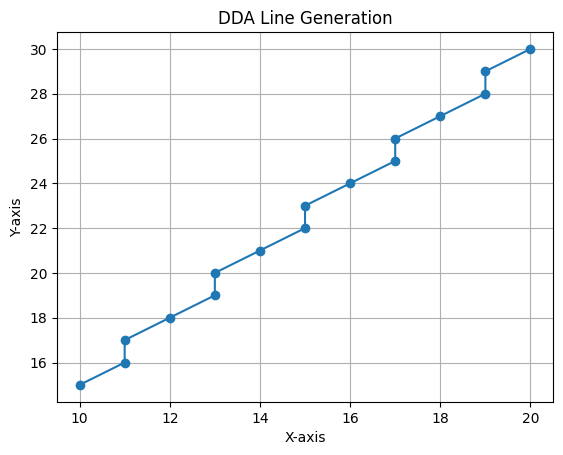

In [11]:
import matplotlib.pyplot as plt

def DDA(x0, y0, x1, y1):
    dx = x1 - x0
    dy = y1 - y0

    steps = int(max(abs(dx), abs(dy)))

    if steps == 0:
        print("Generated Coordinates:", [(x0, y0)])
        return

    xinc = dx / steps
    yinc = dy / steps

    x = float(x0)
    y = float(y0)

    x_coordinates = []
    y_coordinates = []

    for i in range(steps + 1):
        x_coordinates.append(round(x))
        y_coordinates.append(round(y))
        x += xinc
        y += yinc

    # Coordinate format output
    coordinates = list(zip(x_coordinates, y_coordinates))
    print("Generated Coordinates:", coordinates)

    # Plot
    plt.plot(x_coordinates, y_coordinates, marker='o')
    plt.title("DDA Line Generation")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.savefig("Exp1_Output.png")
    plt.show()


# Example
DDA(10, 15, 20, 30)

# Experiment No. 2

## Title
**To implement Bresenham’s Line Drawing Algorithm for drawing a straight line between two points**

## Objective
To generate a straight line between two given points using Bresenham’s algorithm and observe efficient pixel plotting without floating-point calculations.

## Theory
Bresenham’s Line Drawing Algorithm is an efficient method for drawing a straight line using only integer calculations. It avoids floating-point operations, making it faster than the DDA algorithm.

For a line between $(x_1, y_1)$ and $(x_2, y_2)$:

$$
dx = x_2 - x_1
$$

$$
dy = y_2 - y_1
$$

The algorithm uses a decision parameter:

$$
p = 2dy - dx
$$

At each step:
- If $p < 0$, the next point is $(x+1, y)$  
- If $p \geq 0$, the next point is $(x+1, y+1)$ and update $p$

The decision parameter is updated incrementally to determine the next pixel position. This method ensures accurate and efficient line generation on raster displays.

## Procedure
1. Input the starting point $(x_0, y_0)$ and ending point $(x_1, y_1)$.
2. Calculate $dx$ and $dy$.
3. Initialize the decision parameter $p = 2dy - dx$.
4. Set the initial point $(x, y) = (x_0, y_0)$.
5. Plot the initial point.
6. For each step:
   - Increment $x$ by 1.
   - If $p < 0$, update $p = p + 2dy$.
   - Else:
     - Increment $y$ by 1.
     - Update $p = p + 2dy - 2dx$.
7. Repeat until the end point is reached.
8. Plot all generated points and display coordinates.

## Output
- A straight line drawn between the given two points
- Generated coordinate points in the format:
  `[(x1, y1), (x2, y2), ...]`
- Output image saved as `Exp2_Output.png`

## Result and Discussion
The Bresenham algorithm successfully generated a straight line using only integer arithmetic. The plotted points form a continuous line with high accuracy. Compared to DDA, this method is more efficient as it avoids floating-point calculations and reduces computational cost.

Generated Coordinates: [(10, 15), (11, 16), (11, 17), (12, 18), (13, 19), (13, 20), (14, 21), (15, 22), (15, 23), (16, 24), (17, 25), (17, 26), (18, 27), (19, 28), (19, 29), (20, 30)]


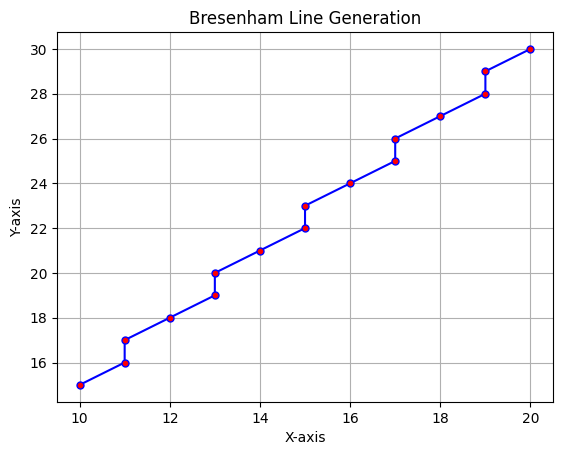

In [1]:
import matplotlib.pyplot as plt

def bresenham(x0, y0, x1, y1):
    x_coordinates = []
    y_coordinates = []

    dx = abs(x1 - x0)
    dy = abs(y1 - y0)

    x, y = x0, y0

    sx = 1 if x1 > x0 else -1
    sy = 1 if y1 > y0 else -1

    if dx > dy:
        p = 2 * dy - dx
        for i in range(dx + 1):
            x_coordinates.append(x)
            y_coordinates.append(y)

            x += sx
            if p < 0:
                p += 2 * dy
            else:
                y += sy
                p += 2 * (dy - dx)
    else:
        p = 2 * dx - dy
        for i in range(dy + 1):
            x_coordinates.append(x)
            y_coordinates.append(y)

            y += sy
            if p < 0:
                p += 2 * dx
            else:
                x += sx
                p += 2 * (dx - dy)

    coordinates = list(zip(x_coordinates, y_coordinates))
    print("Generated Coordinates:", coordinates)

    plt.plot(
        x_coordinates,
        y_coordinates,
        color="blue",
        marker="o",
        markersize=5,
        markerfacecolor="red"
    )
    plt.title("Bresenham Line Generation")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.savefig("Exp2_Output.png")
    plt.show()


# Example
bresenham(10, 15, 20, 30)

# Experiment No. 3

## Title
**To implement the Midpoint Circle Drawing Algorithm for drawing a circle with a given center and radius**

## Objective
To generate a circle using the Midpoint Circle Drawing Algorithm and observe symmetric pixel plotting in different octants.

## Theory
The Midpoint Circle Drawing Algorithm is an efficient method for drawing a circle using integer arithmetic. It is based on the symmetry property of a circle.

For a circle centered at $(x_c, y_c)$ with radius $r$, the initial point is taken as:

$$
x = 0,\qquad y = r
$$

The initial decision parameter is:

$$
p = 1 - r
$$

At each step:
- If $p < 0$, the next point is:
  $$
  x = x + 1
  $$
  and
  $$
  p = p + 2x + 1
  $$

- If $p \geq 0$, the next point is:
  $$
  x = x + 1,\qquad y = y - 1
  $$
  and
  $$
  p = p + 2x - 2y + 1
  $$

Because of symmetry, once a point $(x, y)$ is obtained in one octant, the corresponding points in the other seven octants are:

- $(x_c + x,\; y_c + y)$
- $(x_c - x,\; y_c + y)$
- $(x_c + x,\; y_c - y)$
- $(x_c - x,\; y_c - y)$
- $(x_c + y,\; y_c + x)$
- $(x_c - y,\; y_c + x)$
- $(x_c + y,\; y_c - x)$
- $(x_c - y,\; y_c - x)$

This reduces computation and makes the algorithm efficient for raster displays.

## Procedure
1. Input the center of the circle $(x_c, y_c)$ and radius $r$.
2. Initialize $x = 0$ and $y = r$.
3. Set the initial decision parameter $p = 1 - r$.
4. Plot the initial symmetric points.
5. While $x < y$:
   - Increment $x$ by 1.
   - If $p < 0$, update the decision parameter.
   - Otherwise, decrement $y$ by 1 and update the decision parameter.
6. Plot the eight symmetric points for each calculated point.
7. Display the generated circle and coordinate points.
8. Save the output image.

## Output
- A circle drawn using symmetric pixel positions
- Generated coordinate points in the format:
  `[(x1, y1), (x2, y2), ...]`
- Output image saved as `Exp3_Output.png`

## Result and Discussion
The Midpoint Circle Drawing Algorithm successfully generated a circle using integer calculations. The plotted points showed proper symmetry in all eight octants. The method is efficient and suitable for raster graphics because it avoids floating-point operations and uses the circle’s symmetry to reduce computation.

Generated Coordinates: [(10, 17), (10, 18), (10, 19), (10, 20), (10, 21), (10, 22), (10, 23), (11, 15), (11, 16), (11, 24), (11, 25), (12, 14), (12, 26), (13, 13), (13, 27), (14, 12), (14, 28), (15, 11), (15, 29), (16, 11), (16, 29), (17, 10), (17, 30), (18, 10), (18, 30), (19, 10), (19, 30), (20, 10), (20, 30), (21, 10), (21, 30), (22, 10), (22, 30), (23, 10), (23, 30), (24, 11), (24, 29), (25, 11), (25, 29), (26, 12), (26, 28), (27, 13), (27, 27), (28, 14), (28, 26), (29, 15), (29, 16), (29, 24), (29, 25), (30, 17), (30, 18), (30, 19), (30, 20), (30, 21), (30, 22), (30, 23)]


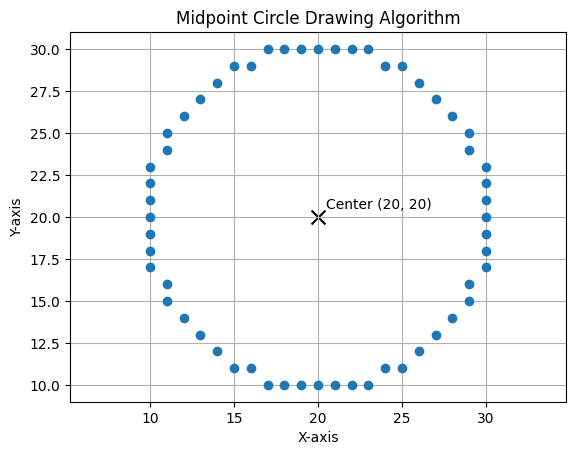

In [1]:
import matplotlib.pyplot as plt

def plot_circle_points(xc, yc, x, y, points):
    symmetric_points = [
        (xc + x, yc + y),
        (xc - x, yc + y),
        (xc + x, yc - y),
        (xc - x, yc - y),
        (xc + y, yc + x),
        (xc - y, yc + x),
        (xc + y, yc - x),
        (xc - y, yc - x)
    ]
    points.extend(symmetric_points)

def midpoint_circle(xc, yc, r):
    x = 0
    y = r
    p = 1 - r

    points = []
    plot_circle_points(xc, yc, x, y, points)

    while x < y:
        x += 1
        if p < 0:
            p = p + 2 * x + 1
        else:
            y -= 1
            p = p + 2 * x - 2 * y + 1
        plot_circle_points(xc, yc, x, y, points)

    points = list(set(points))
    points.sort()

    print("Generated Coordinates:", points)

    x_coordinates = [point[0] for point in points]
    y_coordinates = [point[1] for point in points]

    plt.plot(x_coordinates, y_coordinates, marker='o', linestyle='None')
    plt.scatter(xc, yc, color="black", marker="x", s=100, label="Center")
    plt.text(xc + 0.5, yc + 0.5, f"Center ({xc}, {yc})")
    plt.title("Midpoint Circle Drawing Algorithm")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.axis("equal")
    plt.savefig("Exp3_Output.png")
    plt.show()

# Example
midpoint_circle(20, 20, 10)

# Experiment No. 4

## Title
**To implement Bresenham’s Circle Drawing Algorithm for drawing a circle with a given center and radius**

## Objective
To generate a circle using Bresenham’s Circle Drawing Algorithm and observe symmetric pixel plotting around the center.

## Theory
Bresenham’s Circle Drawing Algorithm is an efficient circle drawing algorithm used in computer graphics. It uses integer-based decision parameters to determine the next pixel position.

For a circle with center $(x_c, y_c)$ and radius $r$, the starting point is:

$$
x = 0,\qquad y = r
$$

The initial decision parameter is:

$$
p = 3 - 2r
$$

At each step:
- If $p < 0$, the next point is selected by increasing $x$ only:

$$
x = x + 1
$$

$$
p = p + 4x + 6
$$

- If $p \geq 0$, both $x$ and $y$ are changed:

$$
x = x + 1,\qquad y = y - 1
$$

$$
p = p + 4(x - y) + 10
$$

Using the symmetry of a circle, one calculated point can generate eight points in different octants. This reduces calculation and makes the algorithm efficient for raster displays.

## Procedure
1. Input the center of the circle $(x_c, y_c)$ and radius $r$.
2. Initialize $x = 0$ and $y = r$.
3. Set the initial decision parameter $p = 3 - 2r$.
4. Plot the eight symmetric points.
5. Repeat while $x \leq y$:
   - If $p < 0$, update $p = p + 4x + 6$.
   - Otherwise, decrement $y$ and update $p = p + 4(x - y) + 10$.
   - Increment $x$.
   - Plot the symmetric points.
6. Display the generated circle and coordinate points.
7. Save the output image.

## Output
- A circle drawn using Bresenham’s Circle Drawing Algorithm
- Generated coordinate points in the format:
  `[(x1, y1), (x2, y2), ...]`
- Output image saved as `Exp4_Output.png`

## Result and Discussion
Bresenham’s Circle Drawing Algorithm successfully generated a circle using integer-based calculations. The plotted points showed symmetry in all eight octants. The algorithm is efficient because it avoids floating-point calculations and uses only simple arithmetic operations.

Generated Coordinates: [(10, 17), (10, 18), (10, 19), (10, 20), (10, 21), (10, 22), (10, 23), (11, 15), (11, 16), (11, 24), (11, 25), (12, 14), (12, 26), (13, 13), (13, 27), (14, 12), (14, 28), (15, 11), (15, 29), (16, 11), (16, 29), (17, 10), (17, 30), (18, 10), (18, 30), (19, 10), (19, 30), (20, 10), (20, 30), (21, 10), (21, 30), (22, 10), (22, 30), (23, 10), (23, 30), (24, 11), (24, 29), (25, 11), (25, 29), (26, 12), (26, 28), (27, 13), (27, 27), (28, 14), (28, 26), (29, 15), (29, 16), (29, 24), (29, 25), (30, 17), (30, 18), (30, 19), (30, 20), (30, 21), (30, 22), (30, 23)]


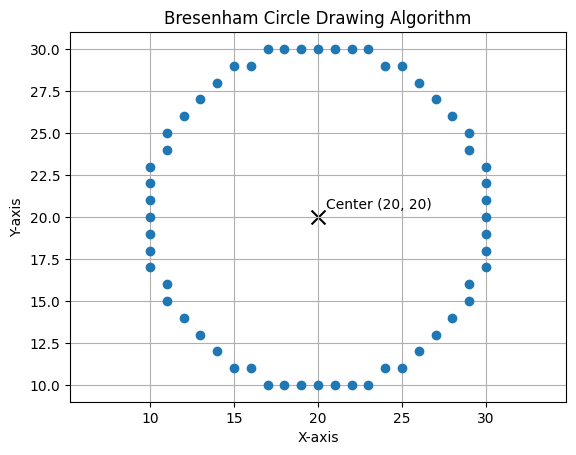

In [1]:
import matplotlib.pyplot as plt

def plot_circle_points(xc, yc, x, y, points):
    symmetric_points = [
        (xc + x, yc + y),
        (xc - x, yc + y),
        (xc + x, yc - y),
        (xc - x, yc - y),
        (xc + y, yc + x),
        (xc - y, yc + x),
        (xc + y, yc - x),
        (xc - y, yc - x)
    ]
    points.extend(symmetric_points)

def bresenham_circle(xc, yc, r):
    x = 0
    y = r
    p = 3 - 2 * r

    points = []

    while x <= y:
        plot_circle_points(xc, yc, x, y, points)

        if p < 0:
            p = p + 4 * x + 6
        else:
            p = p + 4 * (x - y) + 10
            y -= 1

        x += 1

    points = list(set(points))
    points.sort()

    print("Generated Coordinates:", points)

    x_coordinates = [point[0] for point in points]
    y_coordinates = [point[1] for point in points]

    plt.plot(x_coordinates, y_coordinates, marker="o", linestyle="None")
    plt.scatter(xc, yc, color="black", marker="x", s=100, label="Center")
    plt.text(xc + 0.5, yc + 0.5, f"Center ({xc}, {yc})")
    plt.title("Bresenham Circle Drawing Algorithm")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.axis("equal")
    plt.savefig("Exp4_Output.png")
    plt.show()


# Example
bresenham_circle(20, 20, 10)

# Experiment No. 5

## Title
**To implement the Ellipse Drawing Algorithm for drawing an ellipse with a given center and radii**

## Objective
To generate an ellipse using the midpoint ellipse drawing algorithm and observe symmetric pixel plotting in all four quadrants.

## Theory
The Ellipse Drawing Algorithm is used in computer graphics to draw an ellipse on a raster display. An ellipse is symmetric about both the x-axis and y-axis.

For an ellipse centered at $(x_c, y_c)$ with x-radius $r_x$ and y-radius $r_y$, the standard equation is:

$$
\frac{x^2}{r_x^2} + \frac{y^2}{r_y^2} = 1
$$

The midpoint ellipse algorithm divides the ellipse into two regions.

In Region 1, the slope magnitude is less than 1, so x is increased step by step.

In Region 2, the slope magnitude is greater than 1, so y is decreased step by step.

Using symmetry, each calculated point $(x, y)$ generates four points:

- $(x_c + x,\; y_c + y)$
- $(x_c - x,\; y_c + y)$
- $(x_c + x,\; y_c - y)$
- $(x_c - x,\; y_c - y)$

This reduces calculation and makes the algorithm efficient.

## Procedure
1. Input the center of the ellipse $(x_c, y_c)$ and radii $r_x$, $r_y$.
2. Initialize $x = 0$ and $y = r_y$.
3. Calculate the first decision parameter for Region 1.
4. Generate points in Region 1 while $2r_y^2x \leq 2r_x^2y$.
5. Update the decision parameter and plot the symmetric points.
6. Calculate the second decision parameter for Region 2.
7. Generate points in Region 2 while $y \geq 0$.
8. Plot all symmetric points of the ellipse.
9. Display the generated ellipse and save the output image.

## Output
- An ellipse drawn using midpoint ellipse drawing algorithm
- Generated coordinate points in the format:
  `[(x1, y1), (x2, y2), ...]`
- Output image saved as `Exp5_Output.png`

## Result and Discussion
The Ellipse Drawing Algorithm successfully generated an ellipse using midpoint decision parameters. The plotted points showed symmetry in all four quadrants. The algorithm efficiently draws the ellipse by dividing it into two regions and using incremental calculations.

Generated Coordinates: [(10, 16), (10, 17), (10, 18), (10, 19), (10, 20), (10, 21), (10, 22), (10, 23), (10, 24), (11, 13), (11, 14), (11, 15), (11, 25), (11, 26), (11, 27), (12, 11), (12, 12), (12, 28), (12, 29), (13, 9), (13, 10), (13, 30), (13, 31), (14, 8), (14, 32), (15, 7), (15, 33), (16, 6), (16, 34), (17, 6), (17, 34), (18, 5), (18, 35), (19, 5), (19, 35), (20, 5), (20, 35), (21, 5), (21, 35), (22, 5), (22, 35), (23, 6), (23, 34), (24, 6), (24, 34), (25, 7), (25, 33), (26, 8), (26, 32), (27, 9), (27, 10), (27, 30), (27, 31), (28, 11), (28, 12), (28, 28), (28, 29), (29, 13), (29, 14), (29, 15), (29, 25), (29, 26), (29, 27), (30, 16), (30, 17), (30, 18), (30, 19), (30, 20), (30, 21), (30, 22), (30, 23), (30, 24)]


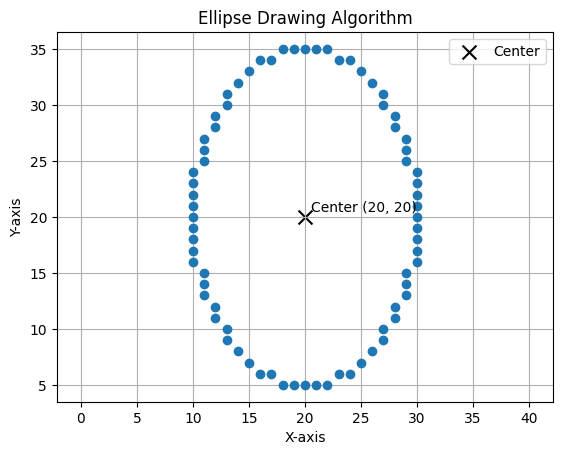

In [12]:
import matplotlib.pyplot as plt

def plot_ellipse_points(xc, yc, x, y, points):
    symmetric_points = [
        (xc + x, yc + y),
        (xc - x, yc + y),
        (xc + x, yc - y),
        (xc - x, yc - y)
    ]
    points.extend(symmetric_points)

def ellipse_drawing(xc, yc, rx, ry):
    x = 0
    y = ry

    rx2 = rx * rx
    ry2 = ry * ry

    p1 = ry2 - (rx2 * ry) + (0.25 * rx2)

    points = []
    plot_ellipse_points(xc, yc, x, y, points)

    while (2 * ry2 * x) <= (2 * rx2 * y):
        x += 1

        if p1 < 0:
            p1 = p1 + (2 * ry2 * x) + ry2
        else:
            y -= 1
            p1 = p1 + (2 * ry2 * x) - (2 * rx2 * y) + ry2

        plot_ellipse_points(xc, yc, x, y, points)

    p2 = (ry2 * (x + 0.5) ** 2) + (rx2 * (y - 1) ** 2) - (rx2 * ry2)

    while y >= 0:
        y -= 1

        if p2 > 0:
            p2 = p2 - (2 * rx2 * y) + rx2
        else:
            x += 1
            p2 = p2 + (2 * ry2 * x) - (2 * rx2 * y) + rx2

        plot_ellipse_points(xc, yc, x, y, points)

    points = list(set(points))
    points.sort()

    print("Generated Coordinates:", points)

    x_coordinates = [point[0] for point in points]
    y_coordinates = [point[1] for point in points]

    # plt.plot(x_coordinates, y_coordinates, marker="o", linestyle="None")
    # plt.title("Ellipse Drawing Algorithm")
    # plt.xlabel("X-axis")
    # plt.ylabel("Y-axis")
    # plt.grid(True)
    # plt.axis("equal")
    # plt.savefig("Exp5_Output.png")
    # plt.show()
    plt.plot(x_coordinates, y_coordinates, marker="o", linestyle="None")

    plt.scatter(xc, yc, color="black", marker="x", s=100, label="Center")
    plt.text(xc + 0.5, yc + 0.5, f"Center ({xc}, {yc})")

    plt.title("Ellipse Drawing Algorithm")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.axis("equal")
    plt.legend()
    plt.savefig("Exp5_Output.png")
    plt.show()


# Example
ellipse_drawing(20, 20, 10, 15)

# Experiment No. 6

## Title
**To implement Two-Dimensional (2D) Transformations on a geometric object**

## Objective
To apply basic 2D transformations such as translation, scaling, rotation, shearing, and reflection on a 2D object and display the results using subplots.

## Theory
Two-dimensional transformations are used in computer graphics to modify the position, size, orientation, and shape of objects. These transformations are commonly represented using matrix operations.

For a point $(x, y)$, transformations can be written in matrix form.

### 1. Translation
Translation shifts an object by $(t_x, t_y)$:

$$
x' = x + t_x,\qquad y' = y + t_y
$$

Matrix form (using homogeneous coordinates):

$$
\begin{bmatrix}
x' \\
y' \\
1
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & t_x \\
0 & 1 & t_y \\
0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
x \\
y \\
1
\end{bmatrix}
$$

---

### 2. Scaling
Scaling changes the size of an object by factors $(s_x, s_y)$:

$$
x' = x \cdot s_x,\qquad y' = y \cdot s_y
$$

Matrix form:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
s_x & 0 \\
0 & s_y
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

---

### 3. Rotation
Rotation rotates an object by an angle $\theta$ about the origin:

$$
x' = x\cos\theta - y\sin\theta
$$

$$
y' = x\sin\theta + y\cos\theta
$$

Matrix form:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

---

### 4. Shearing
Shearing distorts the shape of an object:

$$
x' = x + sh_x \cdot y,\qquad y' = y + sh_y \cdot x
$$

Matrix form:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
1 & sh_x \\
sh_y & 1
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

---

### 5. Reflection
Reflection produces a mirror image of an object.

Reflection about x-axis:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 \\
0 & -1
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

Reflection about y-axis:

$$
\begin{bmatrix}
x' \\
y'
\end{bmatrix}
=
\begin{bmatrix}
-1 & 0 \\
0 & 1
\end{bmatrix}
\begin{bmatrix}
x \\
y
\end{bmatrix}
$$

---

These matrix representations allow transformations to be performed efficiently and are widely used in computer graphics systems.

## Procedure
1. Define the coordinates of a 2D object.
2. Apply translation using translation factors.
3. Apply scaling using scaling factors.
4. Apply rotation using a given angle.
5. Apply shearing using shear factors.
6. Apply reflection about the x-axis.
7. Plot the original and transformed objects using subplots.
8. Save the output image.

## Output
- Original object
- Translated object
- Scaled object
- Rotated object
- Sheared object
- Reflected object
- Output image saved as `Exp6_Output.png`

## Result and Discussion
The 2D transformations were successfully applied to the given object. Translation changed the object’s position, scaling changed its size, rotation changed its orientation, shearing slanted its shape, and reflection produced a mirror image. The subplot representation made it easy to compare the original object with each transformed result.

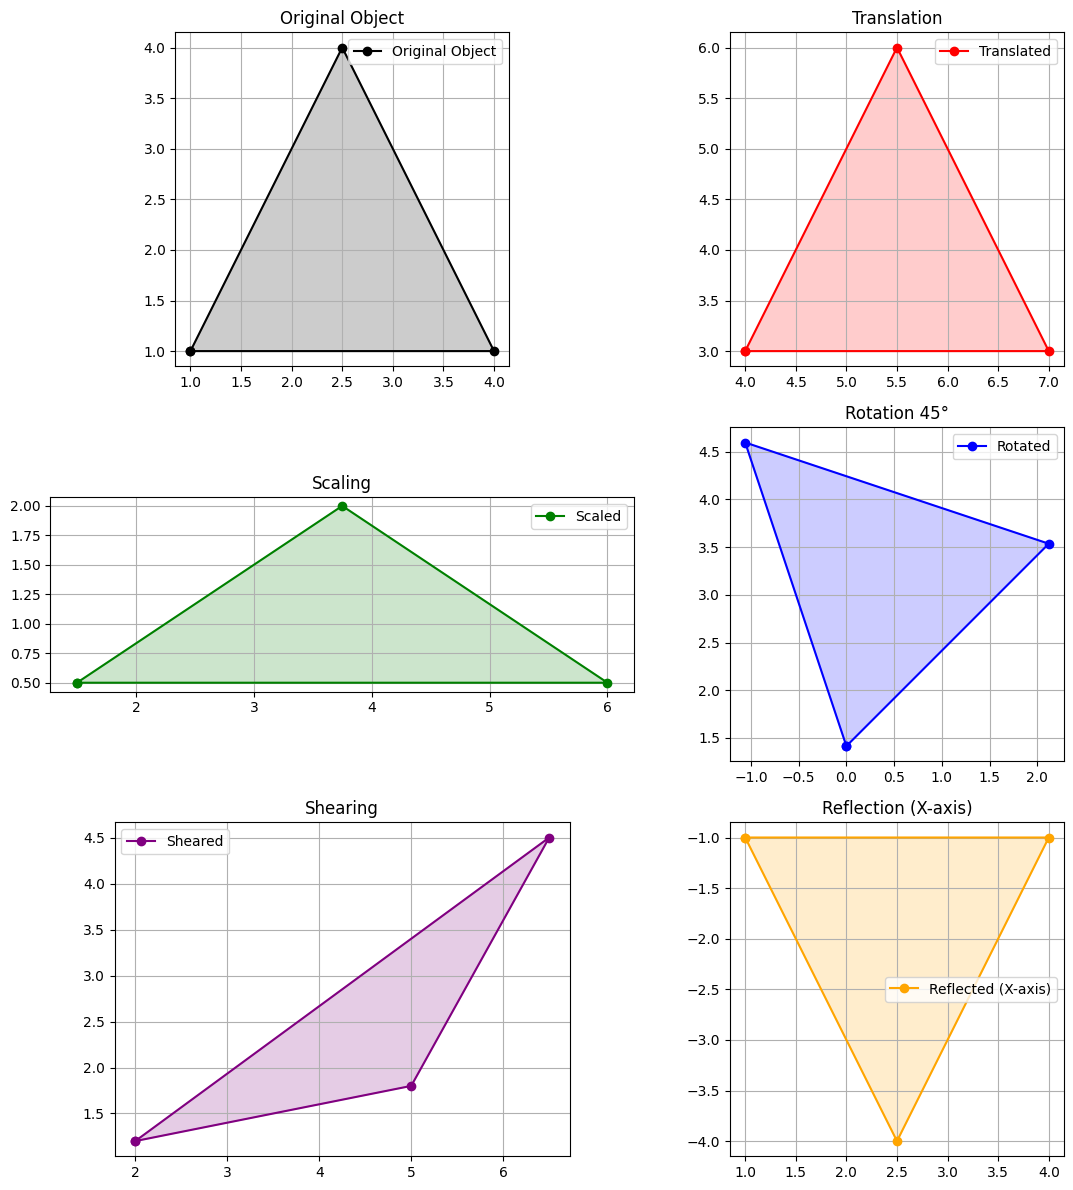

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_shape(ax, points, label, color):
    x = points[:, 0]
    y = points[:, 1]

    ax.plot(x, y, color=color, marker="o", label=label)
    ax.fill(x, y, color=color, alpha=0.2)
    ax.set_aspect("equal")
    ax.grid(True)
    ax.legend()

def add_homogeneous(points):
    ones = np.ones((points.shape[0], 1))
    return np.hstack([points, ones])

def apply_transform(points, matrix):
    homogeneous = add_homogeneous(points)
    transformed = homogeneous @ matrix.T
    return transformed[:, :2]

def translation(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])

def scaling(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ])

def rotation(angle_deg):
    rad = np.radians(angle_deg)
    return np.array([
        [np.cos(rad), -np.sin(rad), 0],
        [np.sin(rad),  np.cos(rad), 0],
        [0, 0, 1]
    ])

def shearing(shx, shy):
    return np.array([
        [1, shx, 0],
        [shy, 1, 0],
        [0, 0, 1]
    ])

def reflection(axis):
    if axis == "x":
        return np.array([
            [1, 0, 0],
            [0, -1, 0],
            [0, 0, 1]
        ])
    elif axis == "y":
        return np.array([
            [-1, 0, 0],
            [0, 1, 0],
            [0, 0, 1]
        ])
    elif axis == "origin":
        return np.array([
            [-1, 0, 0],
            [0, -1, 0],
            [0, 0, 1]
        ])
    else:
        raise ValueError("Axis must be 'x', 'y', or 'origin'")

object_points = np.array([
    [1, 1],
    [4, 1],
    [2.5, 4],
    [1, 1]
])

translated = apply_transform(object_points, translation(3, 2))
scaled = apply_transform(object_points, scaling(1.5, 0.5))
rotated = apply_transform(object_points, rotation(45))
sheared = apply_transform(object_points, shearing(1, 0.2))
reflected = apply_transform(object_points, reflection("x"))

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

plot_shape(axes[0], object_points, "Original Object", "black")
axes[0].set_title("Original Object")

plot_shape(axes[1], translated, "Translated", "red")
axes[1].set_title("Translation")

plot_shape(axes[2], scaled, "Scaled", "green")
axes[2].set_title("Scaling")

plot_shape(axes[3], rotated, "Rotated", "blue")
axes[3].set_title("Rotation 45°")

plot_shape(axes[4], sheared, "Sheared", "purple")
axes[4].set_title("Shearing")

plot_shape(axes[5], reflected, "Reflected (X-axis)", "orange")
axes[5].set_title("Reflection (X-axis)")

plt.tight_layout()
plt.savefig("Exp6_Output.png")
plt.show()

# Experiment No. 7

## Title
**To implement the Cohen–Sutherland Line Clipping Algorithm for clipping a line within a rectangular window**

## Objective
To clip a line segment using the Cohen–Sutherland algorithm so that only the visible portion inside a rectangular clipping window is displayed.

## Theory
The Cohen–Sutherland Line Clipping Algorithm is used in computer graphics to clip a line segment so that only the portion inside a defined rectangular window is visible.

The algorithm assigns a 4-bit region code (Outcode) to each endpoint based on its position relative to the clipping window:

- Top → 1000  
- Bottom → 0100  
- Right → 0010  
- Left → 0001  

Each point is classified as:
- Inside (0000)
- Outside (non-zero code)

### Cases:
1. **Trivial Acceptance**:  
   If both endpoints have region code 0000 → line is completely inside.

2. **Trivial Rejection**:  
   If logical AND of both region codes ≠ 0 → line is completely outside.

3. **Partial Clipping**:  
   Otherwise, the line intersects the window. Intersection points are calculated and the line is clipped accordingly.

Intersection formulas:

- For vertical boundary:
$$
x = x_{boundary}
$$
$$
y = y_1 + m(x - x_1)
$$

- For horizontal boundary:
$$
y = y_{boundary}
$$
$$
x = x_1 + \frac{(y - y_1)}{m}
$$

Where:
$$
m = \frac{y_2 - y_1}{x_2 - x_1}
$$

## Procedure
1. Define the clipping window boundaries $(x_{min}, y_{min})$ and $(x_{max}, y_{max})$.
2. Input the endpoints of the line.
3. Compute region codes for both endpoints.
4. Check for trivial acceptance or rejection.
5. If partially inside, compute intersection with clipping boundary.
6. Replace the outside point with intersection point.
7. Repeat until the line is accepted or rejected.
8. Plot the original and clipped line.

## Output
- Original line
- Clipped line inside the rectangular window
- Clipping window displayed
- Output image saved as `Exp7_Output.png`

## Result and Discussion
The Cohen–Sutherland algorithm successfully clipped the given line according to the defined window. The visible portion of the line was correctly displayed inside the clipping region. The use of region codes made the algorithm efficient in determining whether to accept, reject, or partially clip the line.

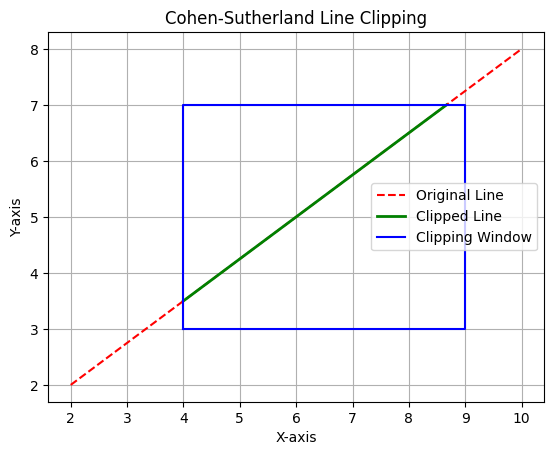

In [1]:
import matplotlib.pyplot as plt

# Define region codes
INSIDE = 0
LEFT = 1
RIGHT = 2
BOTTOM = 4
TOP = 8

def compute_code(x, y, xmin, ymin, xmax, ymax):
    code = INSIDE

    if x < xmin:
        code |= LEFT
    elif x > xmax:
        code |= RIGHT
    if y < ymin:
        code |= BOTTOM
    elif y > ymax:
        code |= TOP

    return code

def cohen_sutherland(x1, y1, x2, y2, xmin, ymin, xmax, ymax):
    code1 = compute_code(x1, y1, xmin, ymin, xmax, ymax)
    code2 = compute_code(x2, y2, xmin, ymin, xmax, ymax)

    accept = False

    while True:
        if code1 == 0 and code2 == 0:
            accept = True
            break
        elif (code1 & code2) != 0:
            break
        else:
            x = y = 0

            if code1 != 0:
                code_out = code1
            else:
                code_out = code2

            if code_out & TOP:
                x = x1 + (x2 - x1) * (ymax - y1) / (y2 - y1)
                y = ymax
            elif code_out & BOTTOM:
                x = x1 + (x2 - x1) * (ymin - y1) / (y2 - y1)
                y = ymin
            elif code_out & RIGHT:
                y = y1 + (y2 - y1) * (xmax - x1) / (x2 - x1)
                x = xmax
            elif code_out & LEFT:
                y = y1 + (y2 - y1) * (xmin - x1) / (x2 - x1)
                x = xmin

            if code_out == code1:
                x1, y1 = x, y
                code1 = compute_code(x1, y1, xmin, ymin, xmax, ymax)
            else:
                x2, y2 = x, y
                code2 = compute_code(x2, y2, xmin, ymin, xmax, ymax)

    return accept, x1, y1, x2, y2


# Example input
x1, y1 = 2, 2
x2, y2 = 10, 8

xmin, ymin = 4, 3
xmax, ymax = 9, 7

accept, cx1, cy1, cx2, cy2 = cohen_sutherland(x1, y1, x2, y2, xmin, ymin, xmax, ymax)

# Plotting
plt.plot([x1, x2], [y1, y2], 'r--', label="Original Line")

if accept:
    plt.plot([cx1, cx2], [cy1, cy2], 'g', linewidth=2, label="Clipped Line")

# Draw clipping window
plt.plot([xmin, xmax, xmax, xmin, xmin],
         [ymin, ymin, ymax, ymax, ymin], 'b', label="Clipping Window")

plt.title("Cohen-Sutherland Line Clipping")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.legend()
plt.savefig("Exp7_Output.png")
plt.show()

# Experiment No. 8

## Title
**To implement the Liang–Barsky Line Clipping Algorithm for clipping a line within a rectangular window**

## Objective
To clip a line segment using the Liang–Barsky algorithm and display only the visible portion inside a rectangular clipping window.

## Theory
The Liang–Barsky Line Clipping Algorithm is an efficient line clipping algorithm used in computer graphics. It uses the parametric form of a line to determine the visible part of the line inside a clipping window.

For a line from $(x_1, y_1)$ to $(x_2, y_2)$, the parametric equation is:

$$
x = x_1 + u(x_2 - x_1)
$$

$$
y = y_1 + u(y_2 - y_1)
$$

where:

$$
0 \leq u \leq 1
$$

Let:

$$
dx = x_2 - x_1
$$

$$
dy = y_2 - y_1
$$

The clipping conditions are represented using:

$$
p = [-dx,\; dx,\; -dy,\; dy]
$$

$$
q = [x_1 - x_{min},\; x_{max} - x_1,\; y_1 - y_{min},\; y_{max} - y_1]
$$

The algorithm calculates two parameters $u_1$ and $u_2$:

- $u_1$ represents the entering point
- $u_2$ represents the leaving point

If $u_1 \leq u_2$, the clipped line is accepted; otherwise, it is rejected.

## Procedure
1. Define the clipping window boundaries $(x_{min}, y_{min})$ and $(x_{max}, y_{max})$.
2. Input the endpoints of the line.
3. Calculate $dx$ and $dy$.
4. Initialize $u_1 = 0$ and $u_2 = 1$.
5. Calculate arrays $p$ and $q$.
6. For each boundary, calculate $r = q / p$.
7. Update $u_1$ for entering boundaries and $u_2$ for leaving boundaries.
8. If $u_1 \leq u_2$, calculate the clipped line endpoints.
9. Plot the original line, clipped line, and clipping window.
10. Save the output image.

## Output
- Original line
- Clipped line inside the rectangular window
- Clipping window displayed
- Output image saved as `Exp8_Output.png`

## Result and Discussion
The Liang–Barsky algorithm successfully clipped the given line using parametric equations. It efficiently calculated the entering and leaving points of the line with respect to the clipping window. Compared to Cohen–Sutherland, this method requires fewer intersection calculations and is generally more efficient.

Clipped Coordinates: [(4.0, 3.5), (8.666666666666668, 7.0)]


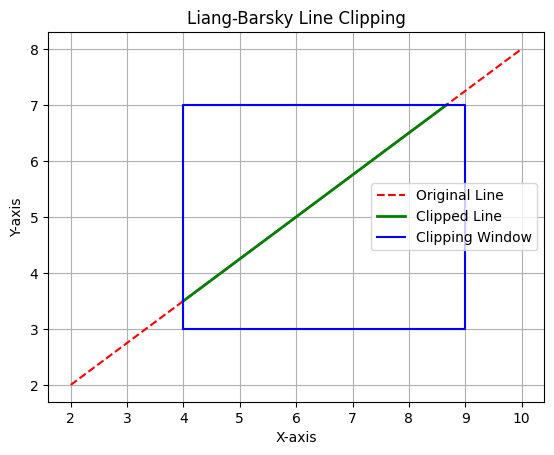

In [1]:
import matplotlib.pyplot as plt

def liang_barsky(x1, y1, x2, y2, xmin, ymin, xmax, ymax):
    dx = x2 - x1
    dy = y2 - y1

    p = [-dx, dx, -dy, dy]
    q = [x1 - xmin, xmax - x1, y1 - ymin, ymax - y1]

    u1 = 0
    u2 = 1

    for i in range(4):
        if p[i] == 0:
            if q[i] < 0:
                return False, None
        else:
            r = q[i] / p[i]

            if p[i] < 0:
                u1 = max(u1, r)
            else:
                u2 = min(u2, r)

    if u1 > u2:
        return False, None

    clipped_x1 = x1 + u1 * dx
    clipped_y1 = y1 + u1 * dy
    clipped_x2 = x1 + u2 * dx
    clipped_y2 = y1 + u2 * dy

    return True, (clipped_x1, clipped_y1, clipped_x2, clipped_y2)


# Example input
x1, y1 = 2, 2
x2, y2 = 10, 8

xmin, ymin = 4, 3
xmax, ymax = 9, 7

accepted, clipped_line = liang_barsky(x1, y1, x2, y2, xmin, ymin, xmax, ymax)

plt.plot([x1, x2], [y1, y2], "r--", label="Original Line")

if accepted:
    cx1, cy1, cx2, cy2 = clipped_line
    print("Clipped Coordinates:", [(cx1, cy1), (cx2, cy2)])
    plt.plot([cx1, cx2], [cy1, cy2], "g", linewidth=2, label="Clipped Line")
else:
    print("Line is completely outside the clipping window.")

plt.plot(
    [xmin, xmax, xmax, xmin, xmin],
    [ymin, ymin, ymax, ymax, ymin],
    "b",
    label="Clipping Window"
)

plt.title("Liang-Barsky Line Clipping")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.legend()
plt.savefig("Exp8_Output.png")
plt.show()

# Experiment No. 9

## Title
**To implement Bezier Curve Generation using control points**

## Objective
To generate a smooth curve using Bezier curve formulation and observe how control points influence the shape of the curve.

## Theory
A Bezier curve is a parametric curve widely used in computer graphics for modeling smooth curves. It is defined using a set of control points.

For a cubic Bezier curve (4 control points), the equation is:

$$
B(t) = (1 - t)^3 P_0 + 3t(1 - t)^2 P_1 + 3t^2(1 - t) P_2 + t^3 P_3
$$

where:
- $0 \leq t \leq 1$
- $P_0, P_1, P_2, P_3$ are control points

General form (n-th degree Bezier curve):

$$
B(t) = \sum_{i=0}^{n} \binom{n}{i} (1 - t)^{n-i} t^i P_i
$$

Bezier curves have the following properties:
- The curve starts at $P_0$ and ends at $P_n$
- The curve lies within the convex hull of control points
- The shape is influenced by intermediate control points

## Procedure
1. Define a set of control points.
2. Choose a parameter $t$ varying from 0 to 1.
3. Compute the Bezier curve using the Bernstein polynomial formula.
4. Generate multiple points along the curve.
5. Plot the control polygon and the Bezier curve.
6. Save the output image.

## Output
- Control points and control polygon
- Smooth Bezier curve
- Output image saved as `Exp9_Output.png`

## Result and Discussion
The Bezier curve was successfully generated using the given control points. The curve smoothly interpolates between the first and last control points while being influenced by intermediate points. The result demonstrates how control points shape the curve without necessarily lying on it.

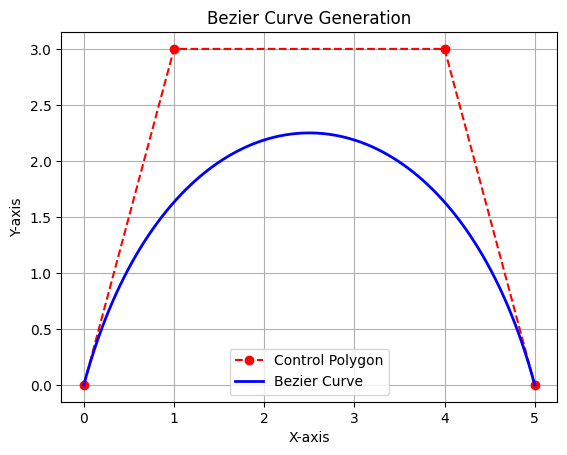

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb

def bezier_curve(control_points, num_points=100):
    n = len(control_points) - 1
    t_values = np.linspace(0, 1, num_points)

    curve_points = []

    for t in t_values:
        point = np.zeros(2)
        for i in range(n + 1):
            bernstein = comb(n, i) * (t ** i) * ((1 - t) ** (n - i))
            point += bernstein * control_points[i]
        curve_points.append(point)

    return np.array(curve_points)

# Define control points
control_points = np.array([
    [0, 0],
    [1, 3],
    [4, 3],
    [5, 0]
])

curve = bezier_curve(control_points)

# Plot
plt.plot(control_points[:, 0], control_points[:, 1], 'ro--', label="Control Polygon")
plt.plot(curve[:, 0], curve[:, 1], 'b', linewidth=2, label="Bezier Curve")

plt.title("Bezier Curve Generation")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.legend()
plt.savefig("Exp9_Output.png")
plt.show()

# Experiment No. 10

## Title
**To implement B-Spline Curve Generation using control points**

## Objective
To generate a smooth B-Spline curve using a set of control points and observe how the control polygon influences the shape of the curve.

## Theory
A B-Spline curve is a smooth piecewise polynomial curve used in computer graphics and geometric modeling. It is controlled by a set of control points, but the curve does not usually pass through all of them.

For a B-Spline curve, the general equation is:

$$
P(t) = \sum_{i=0}^{n} P_i N_{i,k}(t)
$$

where:

- $P_i$ = control points
- $N_{i,k}(t)$ = B-Spline basis function
- $k$ = degree of the curve
- $t$ = curve parameter

The basis function is defined recursively using the Cox-de Boor formula:

$$
N_{i,0}(t) =
\begin{cases}
1, & t_i \leq t < t_{i+1} \\
0, & otherwise
\end{cases}
$$

For degree $k$:

$$
N_{i,k}(t) =
\frac{t - t_i}{t_{i+k} - t_i}N_{i,k-1}(t)
+
\frac{t_{i+k+1} - t}{t_{i+k+1} - t_{i+1}}N_{i+1,k-1}(t)
$$

B-Spline curves are useful because they provide local control, smoothness, and flexibility in curve design.

## Procedure
1. Define a set of control points.
2. Choose the degree of the B-Spline curve.
3. Generate the knot vector.
4. Calculate the B-Spline basis functions.
5. Compute curve points using the weighted sum of control points.
6. Plot the control polygon and generated B-Spline curve.
7. Save the output image.

## Output
- Control points and control polygon
- Smooth B-Spline curve
- Output image saved as `Exp10_Output.png`

## Result and Discussion
The B-Spline curve was successfully generated using the given control points. The curve followed the general shape of the control polygon but did not necessarily pass through all control points. The result shows that B-Spline curves provide smoothness and local control, making them useful for curve modeling in computer graphics.

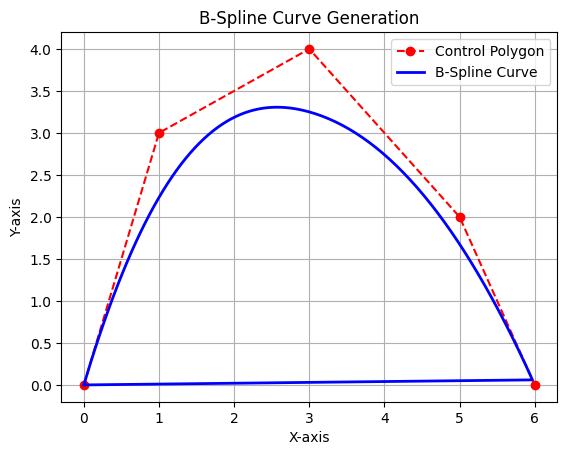

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def b_spline_basis(i, k, t, knots):
    if k == 0:
        if knots[i] <= t < knots[i + 1]:
            return 1
        return 0

    denominator1 = knots[i + k] - knots[i]
    denominator2 = knots[i + k + 1] - knots[i + 1]

    term1 = 0
    term2 = 0

    if denominator1 != 0:
        term1 = ((t - knots[i]) / denominator1) * b_spline_basis(i, k - 1, t, knots)

    if denominator2 != 0:
        term2 = ((knots[i + k + 1] - t) / denominator2) * b_spline_basis(i + 1, k - 1, t, knots)

    return term1 + term2

def b_spline_curve(control_points, degree, num_points=200):
    n = len(control_points) - 1
    knots = np.concatenate((
        np.zeros(degree),
        np.linspace(0, 1, n - degree + 2),
        np.ones(degree)
    ))

    curve_points = []

    for t in np.linspace(0, 1, num_points):
        point = np.zeros(2)

        for i in range(n + 1):
            basis = b_spline_basis(i, degree, t, knots)
            point += basis * control_points[i]

        curve_points.append(point)

    return np.array(curve_points)

# Define control points
control_points = np.array([
    [0, 0],
    [1, 3],
    [3, 4],
    [5, 2],
    [6, 0]
])

degree = 3
curve = b_spline_curve(control_points, degree)

plt.plot(control_points[:, 0], control_points[:, 1], "ro--", label="Control Polygon")
plt.plot(curve[:, 0], curve[:, 1], "b", linewidth=2, label="B-Spline Curve")

plt.title("B-Spline Curve Generation")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.legend()
plt.savefig("Exp10_Output.png")
plt.show()